In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)


# 1-Food Delivery Times Veri Seti

In [19]:
df = pd.read_csv('1-Food_Delivery_Times.csv')

In [20]:
print("Sütunlar:", df.columns.tolist())


Sütunlar: ['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


In [21]:
target = "Delivery_Time_min"   


In [24]:
X = df.drop(columns=[target]).copy()
y = df[target].copy()

# Traffic_level (low/medium/high) -> ordinal
traffic_map = {"low": 0, "medium": 1, "high": 2, "Low": 0, "Medium": 1, "High": 2}
if "Traffic_Level" in X.columns:
    X["Traffic_Level"] = X["Traffic_Level"].map(traffic_map)

X.head()


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs
0,522,7.93,Windy,0.0,Afternoon,Scooter,12,1.0
1,738,16.42,Clear,1.0,Evening,Bike,20,2.0
2,741,9.52,Foggy,0.0,Night,Scooter,28,1.0
3,661,7.44,Rainy,1.0,Afternoon,Scooter,5,1.0
4,412,19.03,Clear,0.0,Morning,Bike,16,5.0


In [25]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Numeric:", len(num_cols), "Categoric:", len(cat_cols))


Numeric: 5 Categoric: 3


In [26]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

results = []
best = None

for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = rmse(y_test, pred)
    results.append((name, score))
    if best is None or score < best[1]:
        best = (name, score, pipe)

results = sorted(results, key=lambda x: x[1])
results, best[0], best[1]


([('LinearRegression', 8.851072147109731),
  ('Ridge', 8.852852088624852),
  ('GradientBoosting', 10.082170141034979),
  ('RandomForest', 10.226860015555987)],
 'LinearRegression',
 8.851072147109731)

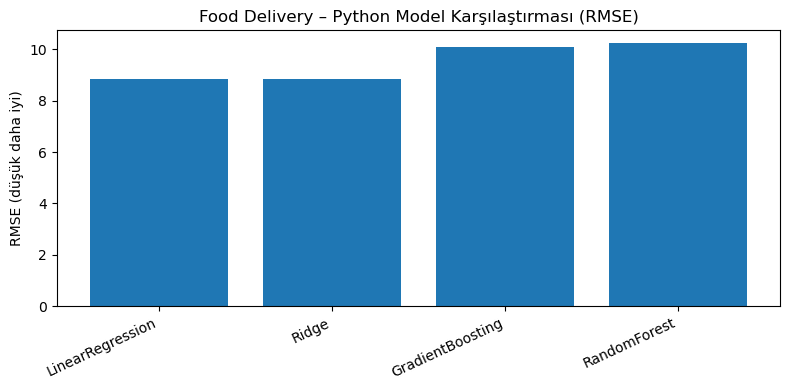

,Model,RMSE
0,LinearRegression,8.851072
1,Ridge,8.852852
2,GradientBoosting,10.082170
3,RandomForest,10.226860


In [27]:
df_res = pd.DataFrame(results, columns=["Model", "RMSE"]).sort_values("RMSE")

plt.figure(figsize=(8,4))
plt.bar(df_res["Model"], df_res["RMSE"])
plt.ylabel("RMSE (düşük daha iyi)")
plt.title("Food Delivery – Python Model Karşılaştırması (RMSE)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

df_res


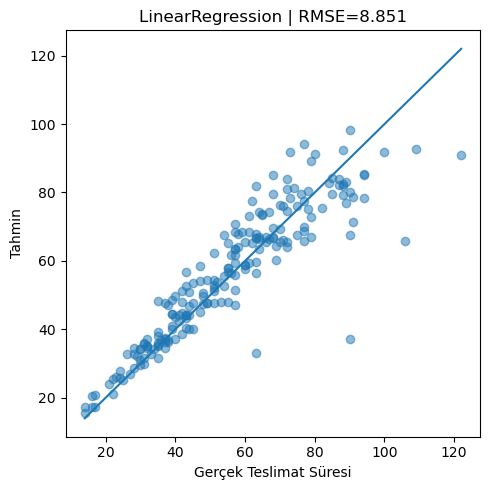

In [28]:
best_name, best_rmse, best_pipe = best
y_pred = best_pipe.predict(X_test)

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.5)
m = min(y_test.min(), y_pred.min())
M = max(y_test.max(), y_pred.max())
plt.plot([m, M], [m, M])
plt.xlabel("Gerçek Teslimat Süresi")
plt.ylabel("Tahmin")
plt.title(f"{best_name} | RMSE={best_rmse:.3f}")
plt.tight_layout()
plt.show()


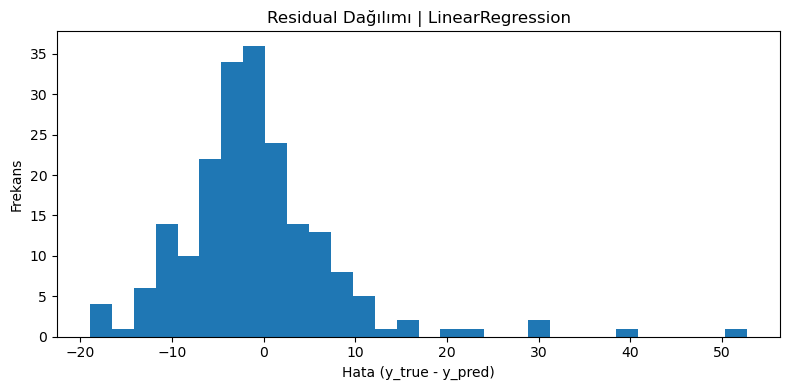

Residual mean: -0.7408492431723936
Residual std : 8.820012502952167


In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30)
plt.xlabel("Hata (y_true - y_pred)")
plt.ylabel("Frekans")
plt.title(f"Residual Dağılımı | {best_name}")
plt.tight_layout()
plt.show()

print("Residual mean:", float(np.mean(residuals)))
print("Residual std :", float(np.std(residuals)))


# 2- Health insurance Veri Seti

In [30]:
df = pd.read_csv("2-Health_insurance.csv")
df.head(), df.shape


(   age     sex     bmi  children smoker     region      charges
 0   19  female  27.900         0    yes  southwest  16884.92400
 1   18    male  33.770         1     no  southeast   1725.55230
 2   28    male  33.000         3     no  southeast   4449.46200
 3   33    male  22.705         0     no  northwest  21984.47061
 4   32    male  28.880         0     no  northwest   3866.85520,
 (1338, 7))

In [31]:
target = "charges"
X = df.drop(columns=[target]).copy()
y = df[target].copy()


In [32]:
X["bmi_category"] = np.where(X["bmi"] > 30, "obese", "non_obese")
X["age_group"] = np.where(X["age"] > 50, "senior", "adult")


In [33]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [34]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

results = []
best = None

for name, model in models.items():
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = rmse(y_test, pred)
    results.append((name, score))
    if best is None or score < best[1]:
        best = (name, score, pipe)

results = sorted(results, key=lambda x: x[1])
results, best[0], best[1]


([('GradientBoosting', 4260.4163762813705),
  ('RandomForest', 4588.564292394108),
  ('LinearRegression', 5750.840152770285),
  ('Ridge', 5752.985339314295)],
 'GradientBoosting',
 4260.4163762813705)

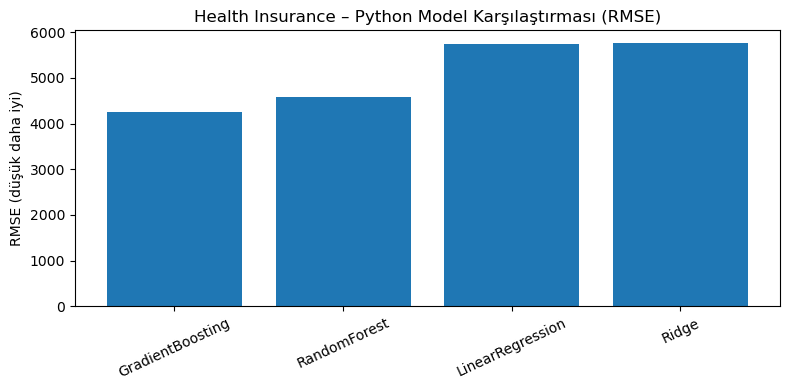

In [35]:
df_res = pd.DataFrame(results, columns=["Model", "RMSE"])

plt.figure(figsize=(8,4))
plt.bar(df_res["Model"], df_res["RMSE"])
plt.ylabel("RMSE (düşük daha iyi)")
plt.title("Health Insurance – Python Model Karşılaştırması (RMSE)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


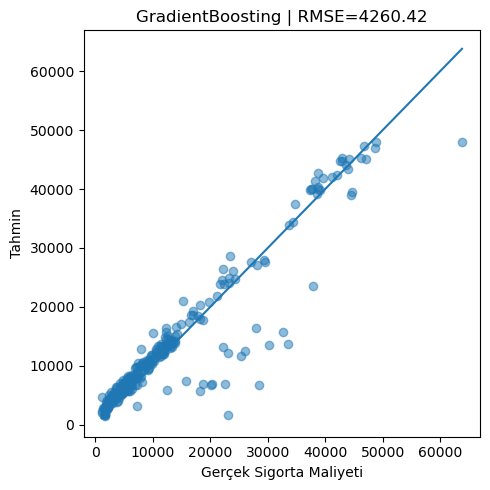

In [36]:
best_name, best_rmse, best_pipe = best
y_pred = best_pipe.predict(X_test)

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.5)
m = min(y_test.min(), y_pred.min())
M = max(y_test.max(), y_pred.max())
plt.plot([m, M], [m, M])
plt.xlabel("Gerçek Sigorta Maliyeti")
plt.ylabel("Tahmin")
plt.title(f"{best_name} | RMSE={best_rmse:.2f}")
plt.tight_layout()
plt.show()


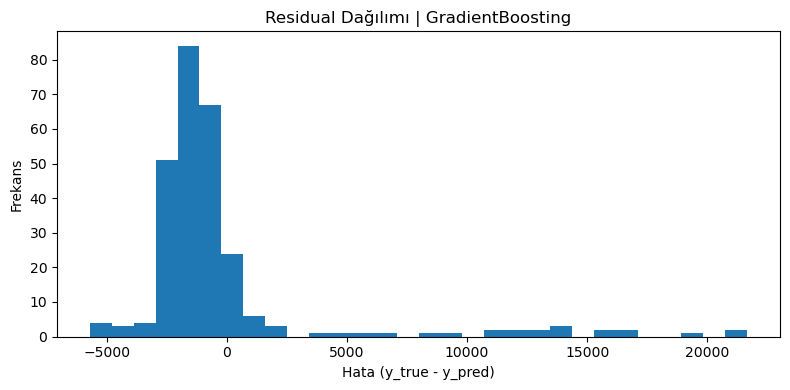

(-177.33734600700407, 4256.723994458379)

In [37]:
residuals = y_test - y_pred

plt.figure(figsize=(8,4))
plt.hist(residuals, bins=30)
plt.xlabel("Hata (y_true - y_pred)")
plt.ylabel("Frekans")
plt.title(f"Residual Dağılımı | {best_name}")
plt.tight_layout()
plt.show()

np.mean(residuals), np.std(residuals)


# 3- uber raw data


In [38]:
df = pd.read_csv("3-uber-raw-data-sep14.csv")  
df.head(), df.shape


(          Date/Time      Lat      Lon    Base
 0  9/1/2014 0:01:00  40.2201 -74.0021  B02512
 1  9/1/2014 0:01:00  40.7500 -74.0027  B02512
 2  9/1/2014 0:03:00  40.7559 -73.9864  B02512
 3  9/1/2014 0:06:00  40.7450 -73.9889  B02512
 4  9/1/2014 0:11:00  40.8145 -73.9444  B02512,
 (1028136, 4))

In [39]:
df["Date/Time"] = pd.to_datetime(df["Date/Time"])

df["day"] = df["Date/Time"].dt.day
df["hour"] = df["Date/Time"].dt.hour
df["weekday"] = df["Date/Time"].dt.weekday


In [40]:
agg = (
    df
    .groupby(["day", "hour", "weekday", "Base"])
    .size()
    .reset_index(name="trip_count")
)

agg.head(), agg.shape


(   day  hour  weekday    Base  trip_count
 0    1     0        0  B02512          17
 1    1     0        0  B02598         163
 2    1     0        0  B02617         291
 3    1     0        0  B02682         129
 4    1     0        0  B02764          99,
 (3594, 5))

In [41]:
target = "trip_count"
X = agg.drop(columns=[target])
y = agg[target]


In [42]:
num_cols = ["day", "hour", "weekday"]
cat_cols = ["Base"]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [43]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []
best = None

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    score = rmse(y_test, pred)
    results.append((name, score))
    if best is None or score < best[1]:
        best = (name, score, pipe)

results = sorted(results, key=lambda x: x[1])
results, best[0], best[1]


([('RandomForest', 34.21759908083479),
  ('GradientBoosting', 61.9382250218927),
  ('LinearRegression', 143.1204714859242)],
 'RandomForest',
 34.21759908083479)

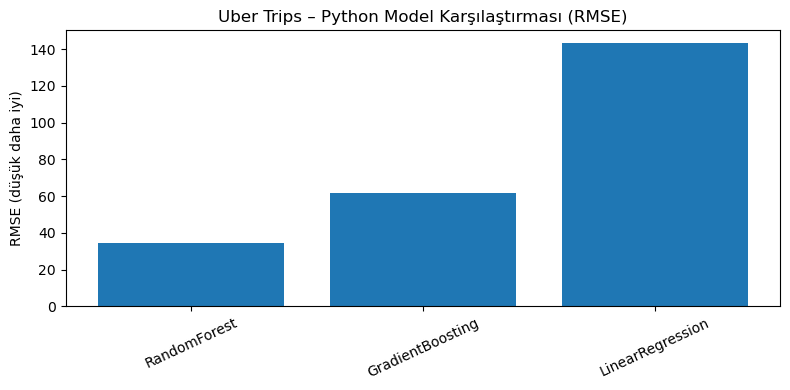

In [44]:
df_res = pd.DataFrame(results, columns=["Model", "RMSE"])

plt.figure(figsize=(8,4))
plt.bar(df_res["Model"], df_res["RMSE"])
plt.ylabel("RMSE (düşük daha iyi)")
plt.title("Uber Trips – Python Model Karşılaştırması (RMSE)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


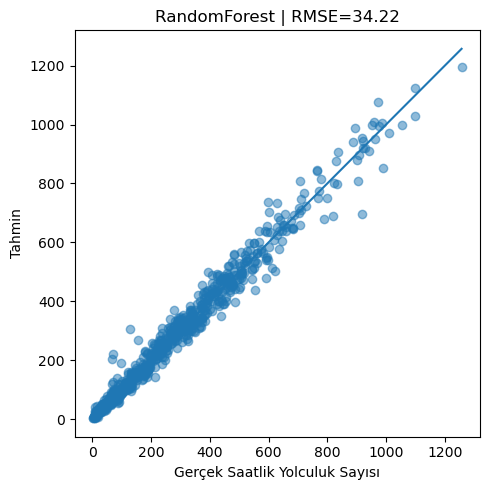

In [45]:
best_name, best_rmse, best_pipe = best
y_pred = best_pipe.predict(X_test)

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.5)
m = min(y_test.min(), y_pred.min())
M = max(y_test.max(), y_pred.max())
plt.plot([m, M], [m, M])
plt.xlabel("Gerçek Saatlik Yolculuk Sayısı")
plt.ylabel("Tahmin")
plt.title(f"{best_name} | RMSE={best_rmse:.2f}")
plt.tight_layout()
plt.show()


# 4- CREDIT CARD CLUSTERING

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [46]:
df = pd.read_csv("4-CC GENERAL.csv")
df.head(), df.shape


(  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
 0  C10001    40.900749           0.818182      95.40              0.00   
 1  C10002  3202.467416           0.909091       0.00              0.00   
 2  C10003  2495.148862           1.000000     773.17            773.17   
 3  C10004  1666.670542           0.636364    1499.00           1499.00   
 4  C10005   817.714335           1.000000      16.00             16.00   
 
    INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
 0                    95.4      0.000000             0.166667   
 1                     0.0   6442.945483             0.000000   
 2                     0.0      0.000000             1.000000   
 3                     0.0    205.788017             0.083333   
 4                     0.0      0.000000             0.083333   
 
    ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
 0                    0.000000                          0.083333   
 1                  

In [47]:
if "CUST_ID" in df.columns:
    df = df.drop(columns=["CUST_ID"])


In [48]:
df.isnull().sum().sort_values(ascending=False).head()


MINIMUM_PAYMENTS          313
CREDIT_LIMIT                1
BALANCE                     0
CASH_ADVANCE_FREQUENCY      0
PRC_FULL_PAYMENT            0
dtype: int64

In [49]:
df = df.fillna(df.median(numeric_only=True))


In [50]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


In [53]:
k = 4

kmeans = KMeans(
    n_clusters=k,
    init="k-means++",
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters


C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [54]:
sil_score = silhouette_score(X_scaled, clusters)
sil_score


0.1976791965228765

In [55]:
cluster_summary = (
    df
    .groupby("Cluster")
    .mean()
)

cluster_summary


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.658327,0.789924,270.041785,209.937299,60.371441,596.509903,0.170145,0.086301,0.080558,0.114846,2.125471,2.903193,3278.640516,974.260054,553.900449,0.077981,11.446568
1,3551.153761,0.986879,7681.620098,5095.878826,2587.208264,653.638891,0.946418,0.739031,0.788060,0.071290,2.085575,89.359413,9696.943765,7288.739497,1972.767288,0.286707,11.951100
2,4602.449658,0.968389,501.862982,320.188797,181.759123,4521.509581,0.287832,0.138911,0.185671,0.484792,14.294904,7.665831,7546.160857,3484.054216,2003.674460,0.034888,11.386800
3,894.907458,0.934734,1236.178934,593.974874,642.478274,210.570626,0.885165,0.297070,0.711842,0.042573,0.790021,22.091773,4213.207678,1332.194205,639.677258,0.269258,11.594595


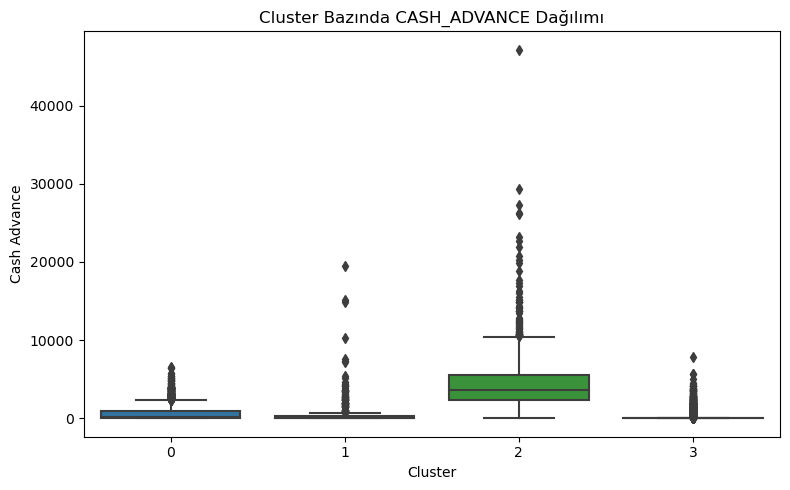

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="Cluster", y="CASH_ADVANCE", data=df)
plt.title("Cluster Bazında CASH_ADVANCE Dağılımı")
plt.xlabel("Cluster")
plt.ylabel("Cash Advance")
plt.tight_layout()
plt.show()


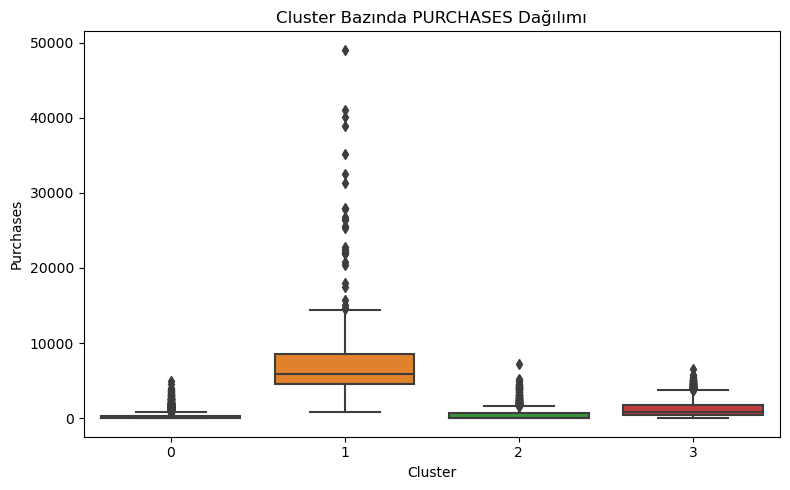

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Cluster", y="PURCHASES", data=df)
plt.title("Cluster Bazında PURCHASES Dağılımı")
plt.xlabel("Cluster")
plt.ylabel("Purchases")
plt.tight_layout()
plt.show()


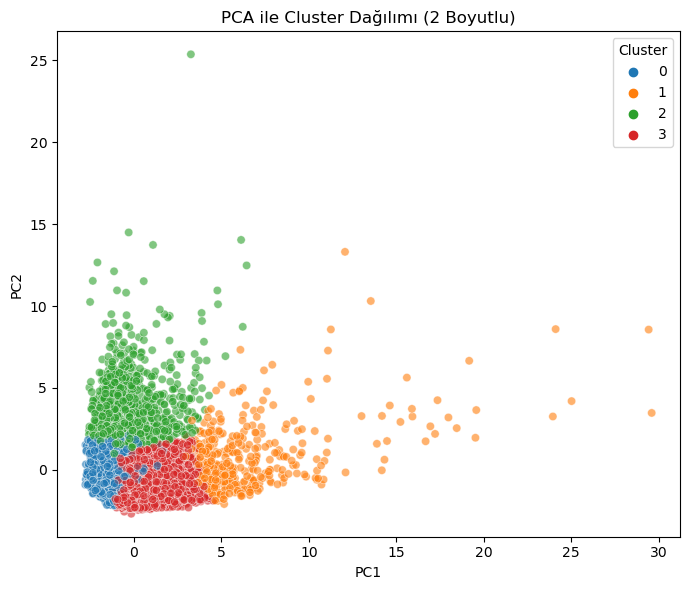

In [58]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": df["Cluster"]
})

plt.figure(figsize=(7,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.6
)
plt.title("PCA ile Cluster Dağılımı (2 Boyutlu)")
plt.tight_layout()
plt.show()


In [59]:
import pandas as pd
import glob

# CSV dosyalarının bulunduğu klasör
path = r"spam/*.csv"   # gerekirse tam yol yaz: C:/.../spam/*.csv

files = glob.glob(path)

df_list = []
for file in files:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

df.head(), df.shape


(                                    COMMENT_ID            AUTHOR  \
 0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
 1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
 2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
 3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
 4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   
 
                   DATE                                            CONTENT  \
 0  2013-11-07T06:20:48  Huh, anyway check out this you[tube] channel: ...   
 1  2013-11-07T12:37:15  Hey guys check out my new channel and our firs...   
 2  2013-11-08T17:34:21             just for test I have to say murdev.com   
 3  2013-11-09T08:28:43   me shaking my sexy ass on my channel enjoy ^_^ ﻿   
 4  2013-11-10T16:05:38            watch?v=vtaRGgvGtWQ   Check this out .﻿   
 
    CLASS  
 0      1  
 1      1  
 2      1  
 3      1  
 4      1  ,
 (1956, 5))

In [60]:
df.columns


Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'CLASS'], dtype='object')

In [61]:
df = df[["CONTENT", "CLASS"]]


In [62]:
df["CLASS"].value_counts()


CLASS
1    1005
0     951
Name: count, dtype: int64

In [63]:
from sklearn.model_selection import train_test_split

X = df["CONTENT"]
y = df["CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [64]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

nb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("nb", MultinomialNB())
])

nb_pipe.fit(X_train, y_train)
y_pred_nb = nb_pipe.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

acc_nb, cm_nb


(0.8928571428571429,
 array([[163,  28],
        [ 14, 187]], dtype=int64))

In [65]:
from sklearn.linear_model import LogisticRegression

lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("lr", LogisticRegression(max_iter=1000))
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

acc_lr, cm_lr


(0.9336734693877551,
 array([[182,   9],
        [ 17, 184]], dtype=int64))

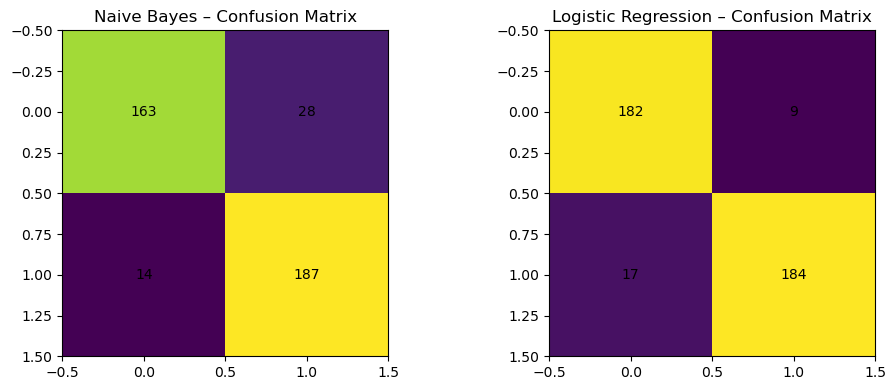

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].imshow(cm_nb)
ax[0].set_title("Naive Bayes – Confusion Matrix")

ax[1].imshow(cm_lr)
ax[1].set_title("Logistic Regression – Confusion Matrix")

for a, cm in zip(ax, [cm_nb, cm_lr]):
    for i in range(2):
        for j in range(2):
            a.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()
